In [5]:
import numpy as np
import matplotlib.pyplot as plt
import re
import pandas as pd
!pip install pdfminer.six
from pdfminer.high_level import extract_text
!pip install PyPDF2
from PyPDF2 import PdfReader

In [6]:
from google.colab import drive
drive.mount('/content/gdrive')

import os
os.listdir('/content/gdrive/My Drive/AHCA Project')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


['full-statement-of-deficiencies-October-2025',
 'AI_Regulatory_Citation_Analysis_Project_Plan.docx',
 'figures',
 'filtered_data_sets',
 'ahca_data_exploration.ipynb',
 'SOM-Appendix-PP.pdf',
 'ayo_ ahca_data_exploration.ipynb',
 'appendixpp_analysis.ipynb']

##Utility functions

In [7]:
def extract_pdf_text(path):
  """Try pdfminer first; fallback to PyPDF2 for basic extraction."""
  try:
    text = extract_text(path)
    if text and text.strip():
      return text
  except Exception:
    pass
      # Fallback
  reader = PdfReader(path)
  pages = [page.extract_text() or "" for page in reader.pages]
  return "\n".join(pages)

def normalize_whitespace(s):
  if s is None:
    return ""
  s = s.replace("\u00A0", " ")
  s = re.sub(r"[ \t]+", " ", s)
  s = re.sub(r"\n{3,}", "\n\n", s)
  return s.strip()

def strip_headers_and_footers(text):
  """
  Remove common headers/footers that can break parsing.
  Adjust patterns if you see false matches in your output.
  """
  lines = text.split("\n")
  cleaned = []
  for line in lines:
    l = line.strip()
  # Drop frequent header/footer lines
    if not l:
      cleaned.append("")
      continue
    if re.search(r"State Operations Manual", l, flags=re.I):
      continue
    if re.search(r"Appendix PP", l, flags=re.I):
      continue
    if re.match(r"Page \d+ of \d+", l):
      continue
  # Many pages have transmittal indices; keep them only if needed
    cleaned.append(line)
  return "\n".join(cleaned)

In [8]:
def clean_text_basic(s):
  s = s if isinstance(s, str) else ""
  s = s.lower()
  s = re.sub(r"\s+", " ", s).strip()
  return s

In [9]:
def parse_ftags_from_text(text: str) -> pd.DataFrame:
  # Pre-clean
  text = normalize_whitespace(text)
  text = strip_headers_and_footers(text)
  # Regex for F-tag blocks
  block_pat = re.compile(
  r"^\sF\s?(\d{3,4})\b(?:[^\n])\n"   # header line with any trailing content
  r"(.?)"                              # body (non-greedy, across newlines)
  r"(?=^\sF\s?\d{3,4}\b|\Z)",          # stop at next header at line start or end of text
  flags=re.MULTILINE | re.DOTALL
  )

  rows = []
  for m in block_pat.finditer(text):
      tag_num = m.group(1)
      title_frag = (m.group(2) or "").strip()
      body = (m.group(3) or "")
      body = body.strip("\n")

      # Promote first body line to title if header wraps and title is missing
      title = title_frag
      if not title:
          body_lines = body.split("\n")
          if body_lines:
              first_line = body_lines[0].strip()
              if len(first_line) > 0 and len(first_line) < 120 and sum(c in ".;:—-" for c in first_line) < 3:
                  title = first_line
                  body = "\n".join(body_lines[1:]).lstrip("\n")

      # Final cleanup
      title = normalize_whitespace(title)
      body = normalize_whitespace(body)

      # Filter obvious non-content blocks
      if not title and not body:
          continue
      if re.search(r"Transmittals Issued|Revisions to Appendix PP", body, flags=re.I):
          continue

      rows.append({
          "f_tag": f"F{tag_num}",
          "title": title,
          "text": body
      })

  df = pd.DataFrame(rows)

  # Deduplicate F-tags (keep the longest body; PDFs sometimes repeat headers)
  if not df.empty:
      df["len_text"] = df["text"].str.len()
      df = df.sort_values(["f_tag", "len_text"], ascending=[True, False]).drop_duplicates("f_tag")
      df = df.drop(columns=["len_text"]).reset_index(drop=True)

  return df

In [10]:
def parse_by_positions(text):
  # Pre-clean
  text = normalize_whitespace(text)
  text = strip_headers_and_footers(text)
  text = text.replace("\r", "\n").replace("\u00A0", " ")
  # Find line-start headers
  headers = list(re.finditer(r"^\sF\s?(\d{3,4})\b", text, flags=re.MULTILINE))
  rows = []
  for i, m in enumerate(headers):
    tag = m.group(1)
    start = m.start()
    end = headers[i+1].start() if i+1 < len(headers) else len(text)
    block = text[start:end]
    # Split first line (header) from body
    lines = block.split("\n", 1)
    header_line = lines[0]
    body = lines[1] if len(lines) > 1 else ""
    # Title = header text after the tag
    title = re.sub(r"^\sF\s?"+tag+r"\b", "", header_line).strip()
    rows.append({"f_tag": f"F{tag}", "title": title, "text": body.strip()})
  return pd.DataFrame(rows)

## Parse the pdf and create blocks by f-tags

In [11]:

pdf_path = '/content/gdrive/My Drive/AHCA Project/SOM-Appendix-PP.pdf'
raw_text = extract_pdf_text(pdf_path)
ftag_df = parse_by_positions(raw_text)
print(ftag_df.head())
print(f"Extracted {len(ftag_df)} F-tags")

  f_tag title                                               text
0  F540        F540 \n(Rev. 225; Issued: 08-08-24; Effective:...
1  F550        F550 \n(Rev. 232; Issued: 07-23-25; Effective:...
2  F551        (Rev. 173, Issued: 11-22-17, Effective: 11-28-...
3  F552        F552 \n(Rev. 173, Issued: 11-22-17, Effective:...
4  F553        F553 \n\n\n\n\n\n\n\n\n\n\n(Rev. 173, Issued:...
Extracted 215 F-tags


In [12]:
tags = re.findall(r"F\s?\d{3,4}", raw_text)
print("Count of 'Fxxx' anywhere:", len(tags), tags[:20])

Count of 'Fxxx' anywhere: 1255 ['F540', 'F584', 'F620', 'F621', 'F627', 'F628', 'F757', 'F774', 'F842', 'F868', 'F540', 'F550', 'F600', 'F600', 'F622', 'F564', 'F583', 'F561', 'F677', 'F603']


In [13]:
start_tags = re.findall(r"^\s*F\s?\d{3,4}\b", raw_text, flags=re.MULTILINE)
print("Count at line start:", len(start_tags), start_tags[:20])

Count at line start: 251 ['F627', '\nF540', '\nF550', '\n \n \n \n \n \n \n \n \n \n\x0cF551', '\nF552', '\nF553', '\nF554', 'F760', '\nF555', 'F710', '\nF556', '\nF557', 'F689', '\nF558', '\nF559', '\nF560', '\n \n \n \n  \n \n \n \n \n \n \n \n \n\x0cF561', 'F550', '\nF562', '\nF563']


## Vectorization and cosine similarity

Load in JKL citation data

In [14]:
csv_path = '/content/gdrive/My Drive/AHCA Project/filtered_data_sets/analysis_dataset_jkl_top10tags.csv'
citation_filt = pd.read_csv(csv_path)

citation_filt.head()

,facility_name,facility_id,address,city,state,zip,inspection_date,deficiency_tag,scope_severity,complaint,...,eventid,inspection_text,cms_region,source_file,inspection_year,inspection_month,text_length,word_count,text_available,tag_label
0,"WINDSOR HEALTH AND REHABILITATION CENTER, LLC",75011.0,581 POQUONOCK AVE,WINDSOR,CT,6095,2024-03-12,600,J,0,...,DOH311,**NOTE- TERMS IN BRACKETS HAVE BEEN EDITED TO ...,1,text2567_20251001_cms_reg1.xlsx,2024,2024-03,28030,4295,True,F-0600
1,MONTOWESE CENTER FOR HEALTH & REHABILITATION,75017.0,163 QUINNIPIAC AVENUE,NORTH HAVEN,CT,6473,2022-08-16,760,J,0,...,LVIZ11,**NOTE- TERMS IN BRACKETS HAVE BEEN EDITED TO ...,1,text2567_20251001_cms_reg1.xlsx,2022,2022-08,20590,3106,True,F-0760
2,AVERY NURSING HOME/NOBLE BUILDING,75063.0,705 NEW BRITAIN AVE,HARTFORD,CT,6106,2023-12-12,600,J,1,...,JE6F11,**NOTE- TERMS IN BRACKETS HAVE BEEN EDITED TO ...,1,text2567_20251001_cms_reg1.xlsx,2023,2023-12,4524,703,True,F-0600
3,AVERY NURSING HOME/NOBLE BUILDING,75063.0,705 NEW BRITAIN AVE,HARTFORD,CT,6106,2023-12-12,689,J,1,...,JE6F11,**NOTE- TERMS IN BRACKETS HAVE BEEN EDITED TO ...,1,text2567_20251001_cms_reg1.xlsx,2023,2023-12,5483,863,True,F-0689
4,GREENTREE MANOR NURSING AND REHABILITATION CENTER,75113.0,4 GREENTREE DRIVE,WATERFORD,CT,6385,2023-03-22,689,K,1,...,9YDI11,"Based on observations, review of facility docu...",1,text2567_20251001_cms_reg1.xlsx,2023,2023-03,6487,1027,True,F-0689


In [15]:
from sklearn.metrics.pairwise import cosine_similarity

def cosine_sim_mixed(existing_vector, raw_text, vectorizer):
    new_vector = vectorizer.transform([raw_text])
    return cosine_similarity(existing_vector, new_vector)[0][0]

TF-IDF Method: term importance and emphasis

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

ftag_df["text_clean"] = ftag_df["text"].apply(clean_text_basic)
tfidf_vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1,2), min_df=2)
X_ftags = tfidf_vectorizer.fit_transform(ftag_df["text_clean"])  # shape: (n_ftags, vocab)

In [17]:
citation_filt["tfidf_sim"] = None
for index, row in citation_filt.iterrows():
  tag = 'F'+str(citation_filt.loc[index, "deficiency_tag"]);
  loc = np.where(ftag_df["f_tag"]==tag)
  citation_filt.loc[index, "tfidf_sim"] = (cosine_sim_mixed(X_ftags[loc], citation_filt.loc[index, "inspection_text"], tfidf_vectorizer))
  if index % 1000 == 0:
    print('\n'+str(index))



0

1000

2000

3000

4000

5000

6000


,tfidf_sim
count,6817.00000
unique,6789.00000
top,0.00564
freq,11.00000


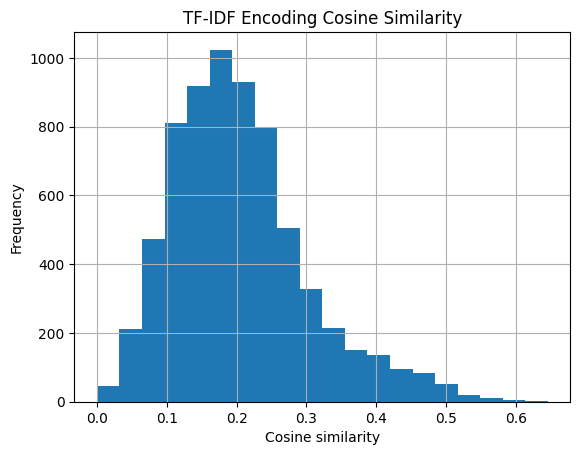

In [18]:
citation_filt["tfidf_sim"].hist(bins=20)
plt.xlabel('Cosine similarity')
plt.ylabel('Frequency')
plt.title('TF-IDF Encoding Cosine Similarity')

citation_filt['tfidf_sim'].describe()


Sentence-transformer embeddings: semantics and similarity

In [19]:
#!pip install sentence-transformers
from sentence_transformers import SentenceTransformer

sentrans_model = SentenceTransformer("all-MiniLM-L6-v2")  # fast + good default
X_sentags = sentrans_model.encode(ftag_df["text_clean"])  # shape: (n_ftags, vocab)
print(X_sentags.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

(215, 384)


In [20]:
citation_filt["sentrans"] = None
for index, row in citation_filt.iterrows():
  tag = 'F'+str(citation_filt.loc[index, "deficiency_tag"]);
  loc = np.where(ftag_df["f_tag"]==tag)
  citation_filt.loc[index, "sentrans"] = X_sentags[loc] @ sentrans_model.encode(citation_filt.loc[index, "inspection_text"]).T
  if index % 1000 == 0:
    print('\n'+str(index))



0

1000

2000

3000

4000

5000

6000


In [21]:
citation_filt['sentrans'] = (
    citation_filt['sentrans']
    .astype(str)
    .str.strip())

citation_filt['sentrans'] = pd.to_numeric(
    citation_filt['sentrans'],
    errors='coerce')

,sentrans
count,6817.000000
mean,0.500246
std,0.112360
min,0.019686
25%,0.432743
50%,0.508144
75%,0.575615
max,0.870374


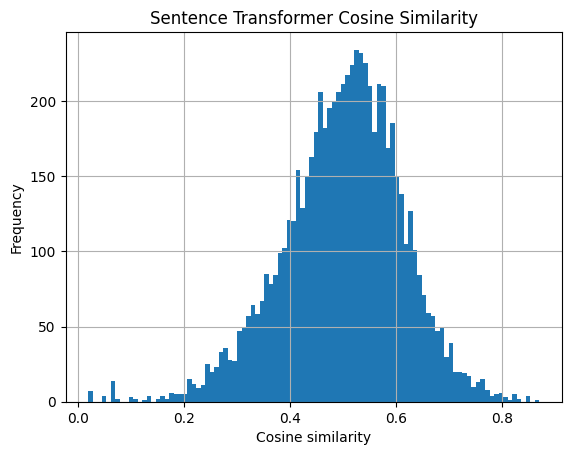

In [22]:
citation_filt["sentrans"].hist(bins=100)
plt.xlabel('Cosine similarity')
plt.ylabel('Frequency')
plt.title('Sentence Transformer Cosine Similarity')

citation_filt['sentrans'].describe()


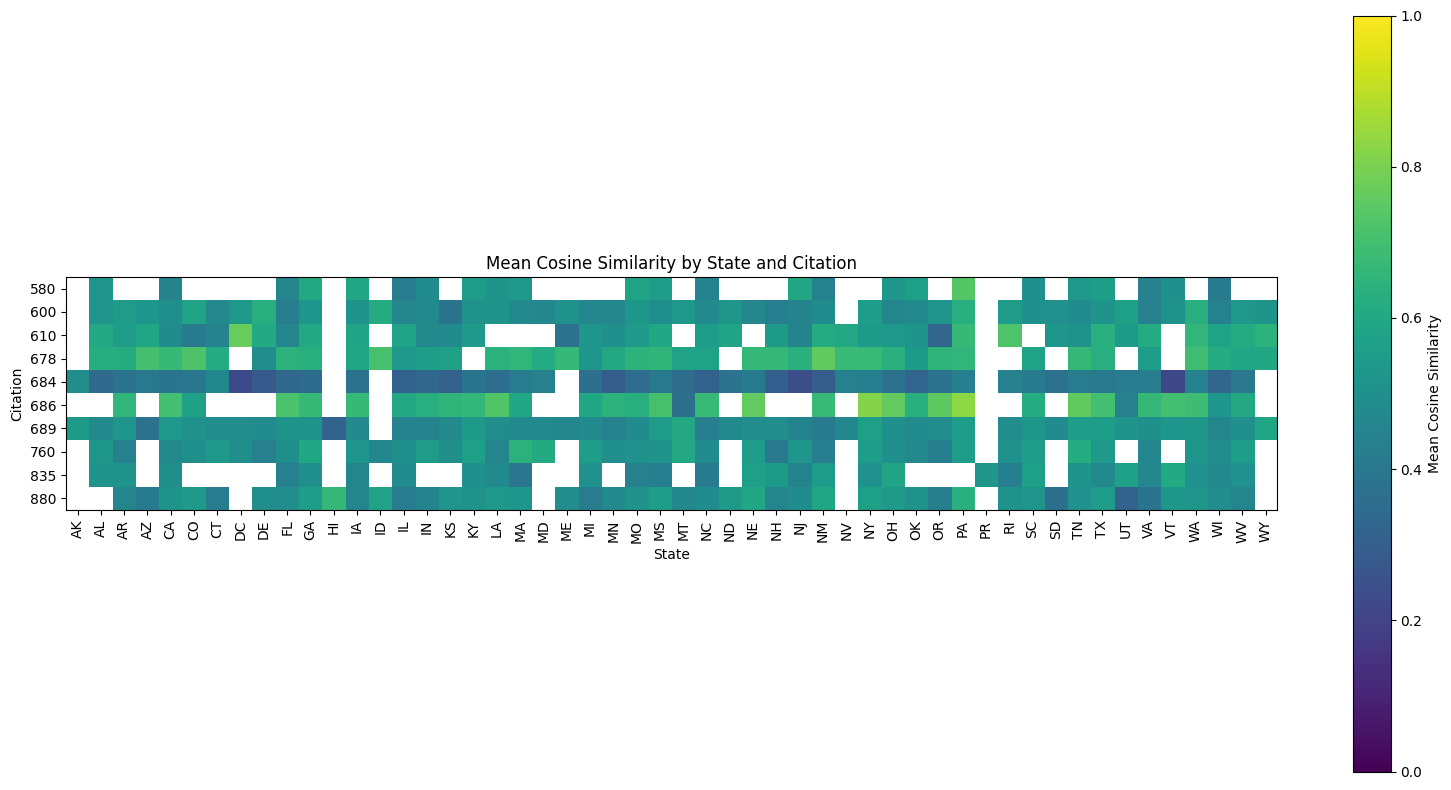

In [23]:
#Mean cosine similarity for top 10 citations by state

top_10_citations = (
    citation_filt['deficiency_tag']
    .value_counts()
    .head(10)
    .index
)

df_top = citation_filt[citation_filt['deficiency_tag'].isin(top_10_citations)]
mean_sim = (
    df_top
    .groupby(['state', 'deficiency_tag'])['sentrans']
    .mean()
    .reset_index()
)
heatmap_data = mean_sim.pivot(
    index='state',
    columns='deficiency_tag',
    values='sentrans'
)
#heatmap_data = heatmap_data.fillna(0)
heatmap_data = heatmap_data.T


plt.figure(figsize=(16, 8))

plt.imshow(
    heatmap_data.values,
    vmin=0,   # cosine similarity lower bound
    vmax=1    # cosine similarity upper bound
)

plt.xticks(
    ticks=np.arange(len(heatmap_data.columns)),
    labels=heatmap_data.columns,
    rotation=90
)

plt.yticks(
    ticks=np.arange(len(heatmap_data.index)),
    labels=heatmap_data.index
)

plt.colorbar(label='Mean Cosine Similarity')

plt.title('Mean Cosine Similarity by State and Citation')
plt.xlabel('State')
plt.ylabel('Citation')

plt.tight_layout()
plt.show()


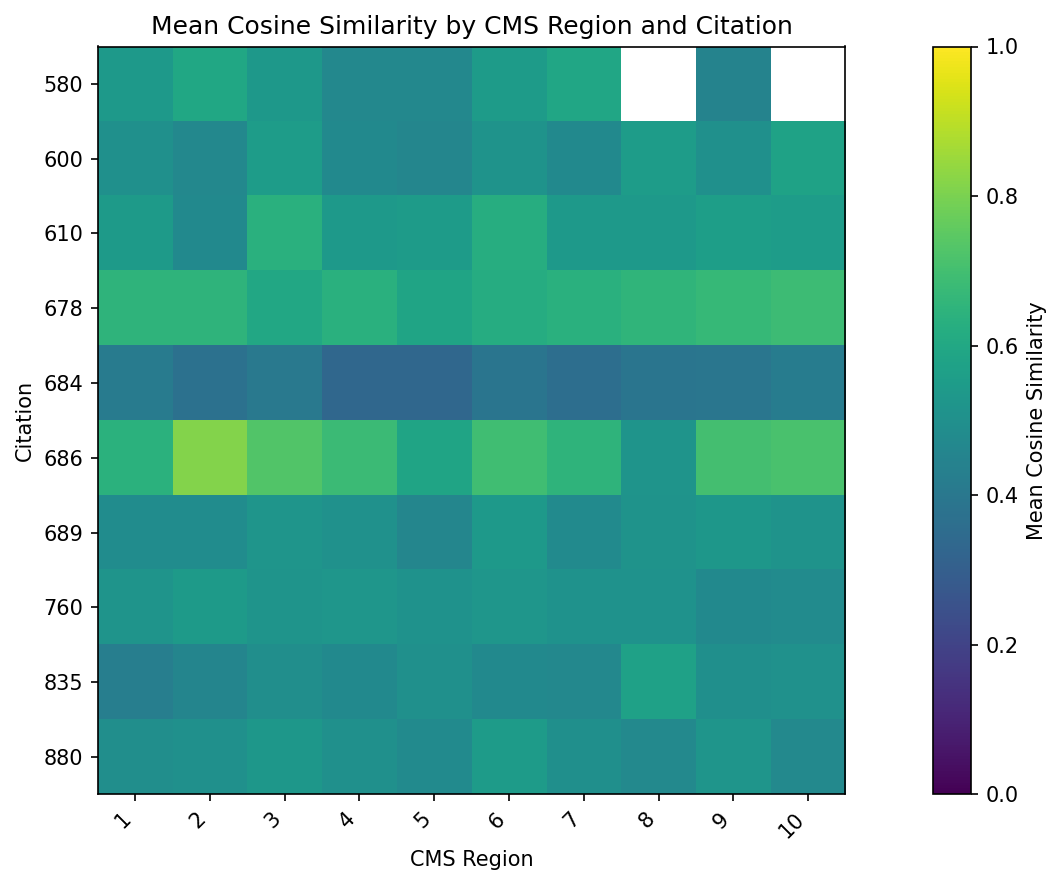

In [24]:
heatmap_data = (
    df_top
    .groupby(['deficiency_tag', 'cms_region'])['sentrans']
    .mean()
    .unstack()
    .astype(float)
)
#heatmap_data = heatmap_data.T

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 6), dpi=150)

im = plt.imshow(
    heatmap_data.values,
    vmin=0,
    vmax=1
)

plt.xticks(
    np.arange(len(heatmap_data.columns)),
    heatmap_data.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    np.arange(len(heatmap_data.index)),
    heatmap_data.index
)

plt.colorbar(im, label='Mean Cosine Similarity')

plt.xlabel('CMS Region')
plt.ylabel('Citation')
plt.title('Mean Cosine Similarity by CMS Region and Citation')

plt.tight_layout()
plt.show()


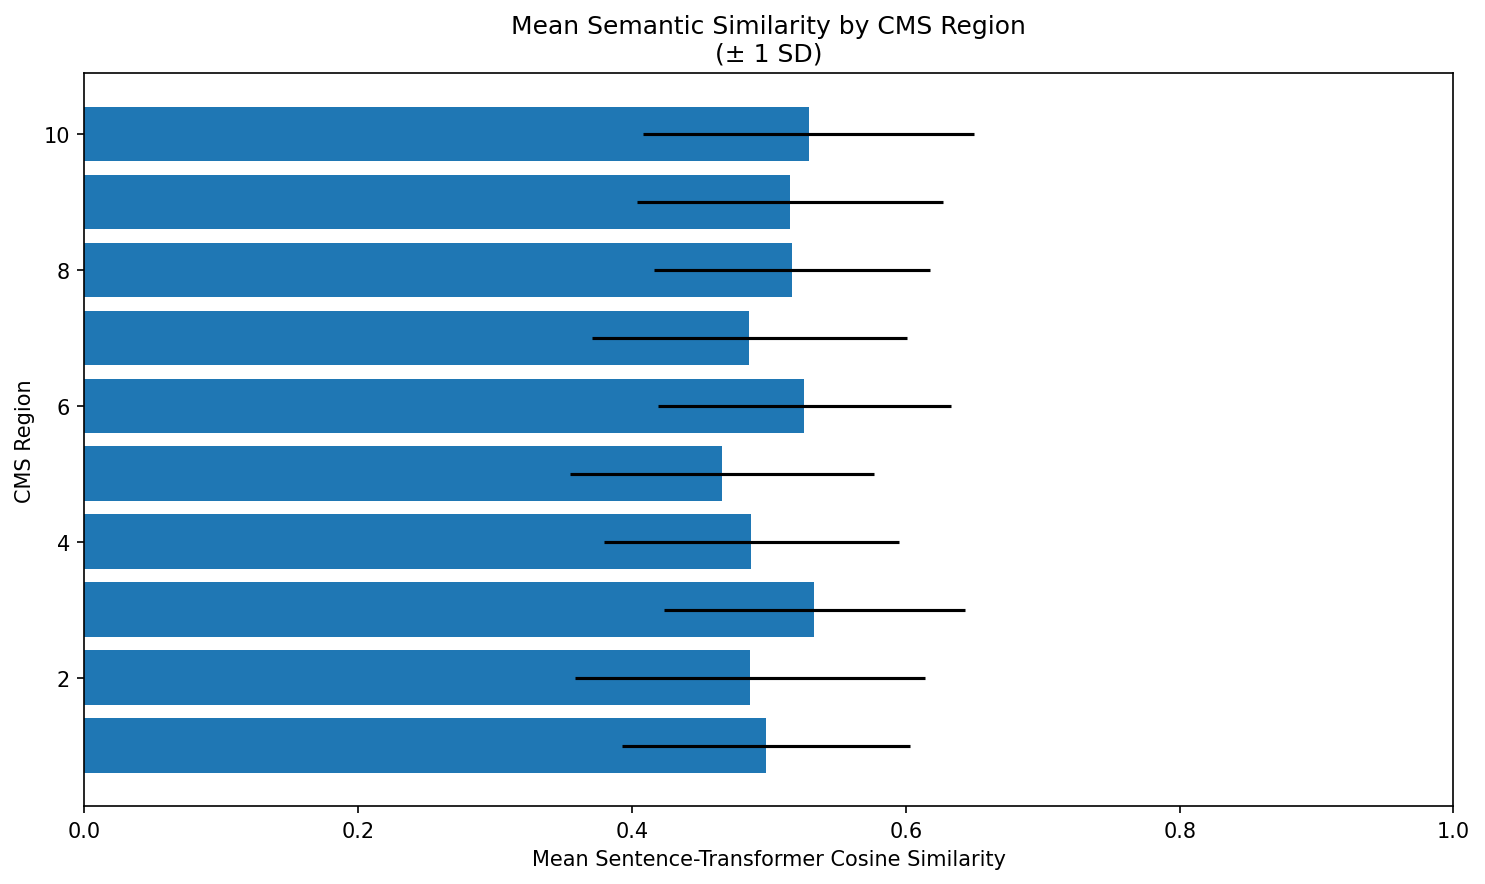

   cms_region      mean       std
4           5  0.465652  0.111112
6           7  0.485669  0.115172
1           2  0.486114  0.127697
3           4  0.487081  0.107900
0           1  0.497770  0.105098
8           9  0.515475  0.111492
7           8  0.516697  0.100973
5           6  0.525838  0.107103
9          10  0.529102  0.121024
2           3  0.533134  0.109853


In [25]:
region_stats = (citation_filt.groupby('cms_region')['sentrans'].agg(['mean', 'std']) .reset_index().sort_values('mean', ascending=True))


plt.figure(figsize=(10, 6), dpi=150)

plt.barh(
    region_stats['cms_region'],
    region_stats['mean'],
    xerr=region_stats['std']
)

plt.xlabel('Mean Sentence-Transformer Cosine Similarity')
plt.ylabel('CMS Region')
plt.title('Mean Semantic Similarity by CMS Region\n(± 1 SD)')

plt.xlim(0, 1)

plt.tight_layout()
plt.show()


print(region_stats)

In [26]:
citation_filt.to_csv("citation_filt.csv", index=False)

In [27]:
citation_filt = pd.read_csv("citation_filt.csv")

# Ensure numeric
citation_filt['sentrans'] = pd.to_numeric(
    citation_filt['sentrans'],
    errors='coerce'
)

# Step 1: Compute State-Level Summary
# State-level stats
state_stats = (
    citation_filt
    .groupby('state')['sentrans']
    .agg(['count', 'mean', 'std'])
    .reset_index()
)

# Step 2: Compute Z-Scores (Deviation from Overall Mean)
overall_mean = citation_filt['sentrans'].mean()
overall_std = citation_filt['sentrans'].std()

state_stats['z_score'] = (
    (state_stats['mean'] - overall_mean) / overall_std
)

state_stats['abs_z'] = state_stats['z_score'].abs()

#Step 3: Identify Top 3 Outlier States
top_outliers = (
    state_stats
    .sort_values('abs_z', ascending=False)
    .head(3)
)

# Keep only states below national mean
low_alignment = state_stats[state_stats['z_score'] < 0].copy()

# Rank by largest negative deviation
low_alignment = low_alignment.sort_values('z_score')

# Top 3 lowest-alignment states
top_low_outliers = low_alignment.head(3)

#Step 4: Print Short Analytical Report
print("\nLow-Alignment State Analysis\n")
print(f"National Mean Similarity: {overall_mean:.4f}")
print(f"National Std Dev: {overall_std:.4f}\n")

print("States with the Lowest Regulatory Alignment (Largest Negative Deviations):\n")

for _, row in top_low_outliers.iterrows():
    print(
        f"- {row['state']}: "
        f"Mean Similarity = {row['mean']:.4f}, "
        f"{abs(row['z_score']):.2f} SD below national mean, "
        f"N = {int(row['count'])}"
    )

print("\nInterpretation:")
print(
    "These states exhibit substantially lower semantic alignment "
    "with the reference regulatory language relative to the national distribution. "
    "Large negative deviations suggest structural divergence in citation usage "
    "or regulatory phrasing."
)


Low-Alignment State Analysis

National Mean Similarity: 0.5002
National Std Dev: 0.1124

States with the Lowest Regulatory Alignment (Largest Negative Deviations):

- NC: Mean Similarity = 0.4329, 0.60 SD below national mean, N = 421
- NM: Mean Similarity = 0.4368, 0.56 SD below national mean, N = 57
- IL: Mean Similarity = 0.4502, 0.45 SD below national mean, N = 372

Interpretation:
These states exhibit substantially lower semantic alignment with the reference regulatory language relative to the national distribution. Large negative deviations suggest structural divergence in citation usage or regulatory phrasing.


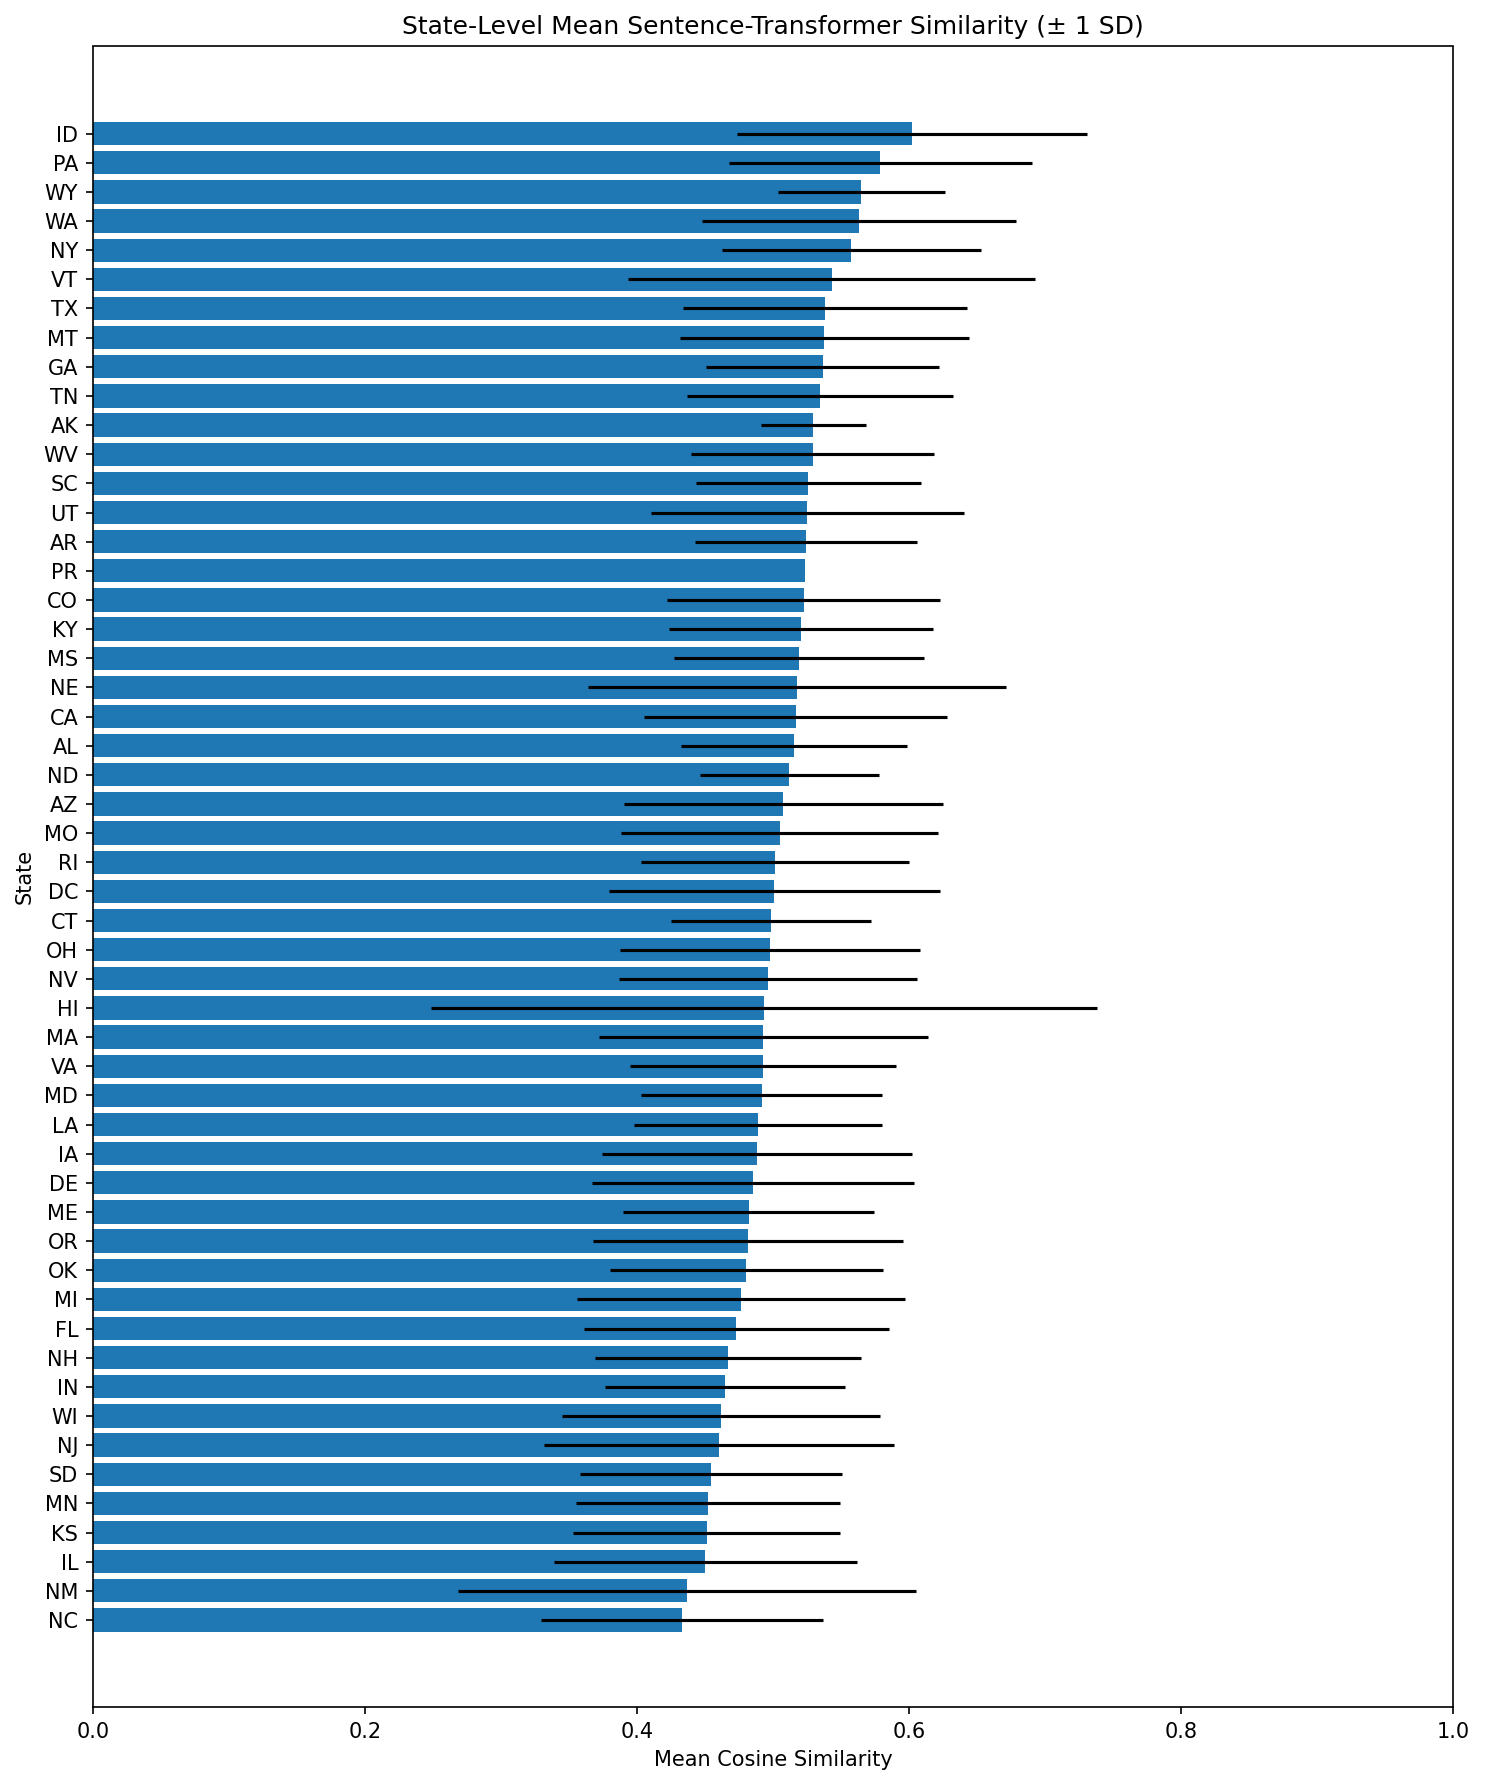

In [28]:

# Compute state means
state_stats = (
    citation_filt
    .groupby('state')['sentrans']
    .agg(['count', 'mean', 'std'])
    .reset_index()
    .sort_values('mean', ascending=True)
)

# Plot
plt.figure(figsize=(10, 12), dpi=150)

plt.barh(
    state_stats['state'],
    state_stats['mean'],
    xerr=state_stats['std']
)

plt.xlabel('Mean Cosine Similarity')
plt.ylabel('State')
plt.title('State-Level Mean Sentence-Transformer Similarity (± 1 SD)')
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

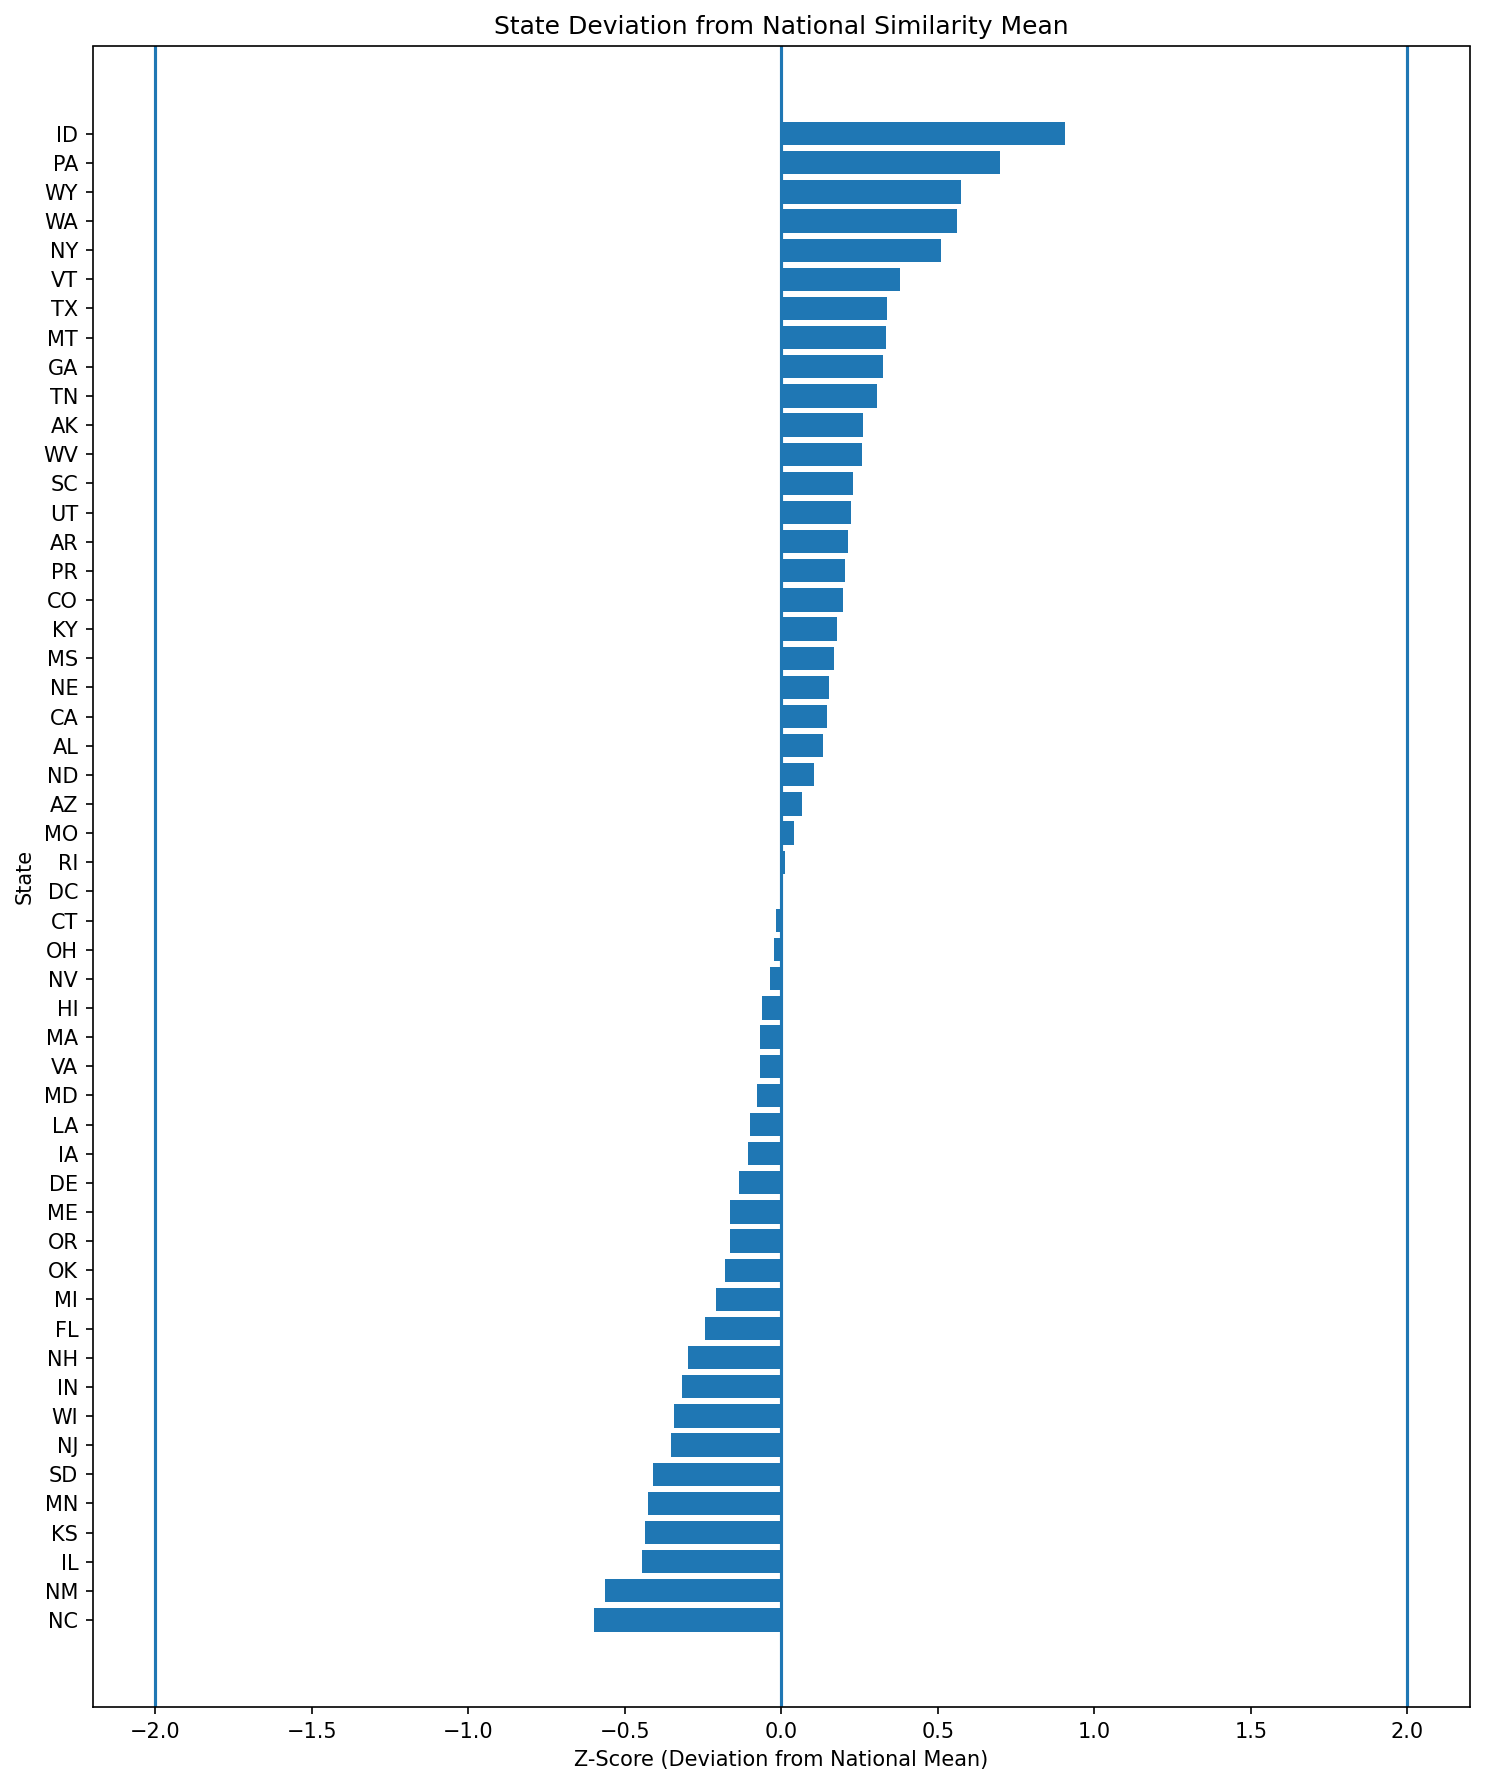

In [29]:
overall_mean = citation_filt['sentrans'].mean()
overall_std = citation_filt['sentrans'].std()

state_stats['z_score'] = (
    (state_stats['mean'] - overall_mean) / overall_std
)

state_stats = state_stats.sort_values('z_score')

plt.figure(figsize=(10, 12), dpi=150)

plt.barh(
    state_stats['state'],
    state_stats['z_score']
)

plt.axvline(0)
plt.axvline(2)
plt.axvline(-2)

plt.xlabel('Z-Score (Deviation from National Mean)')
plt.ylabel('State')
plt.title('State Deviation from National Similarity Mean')

plt.tight_layout()
plt.show()

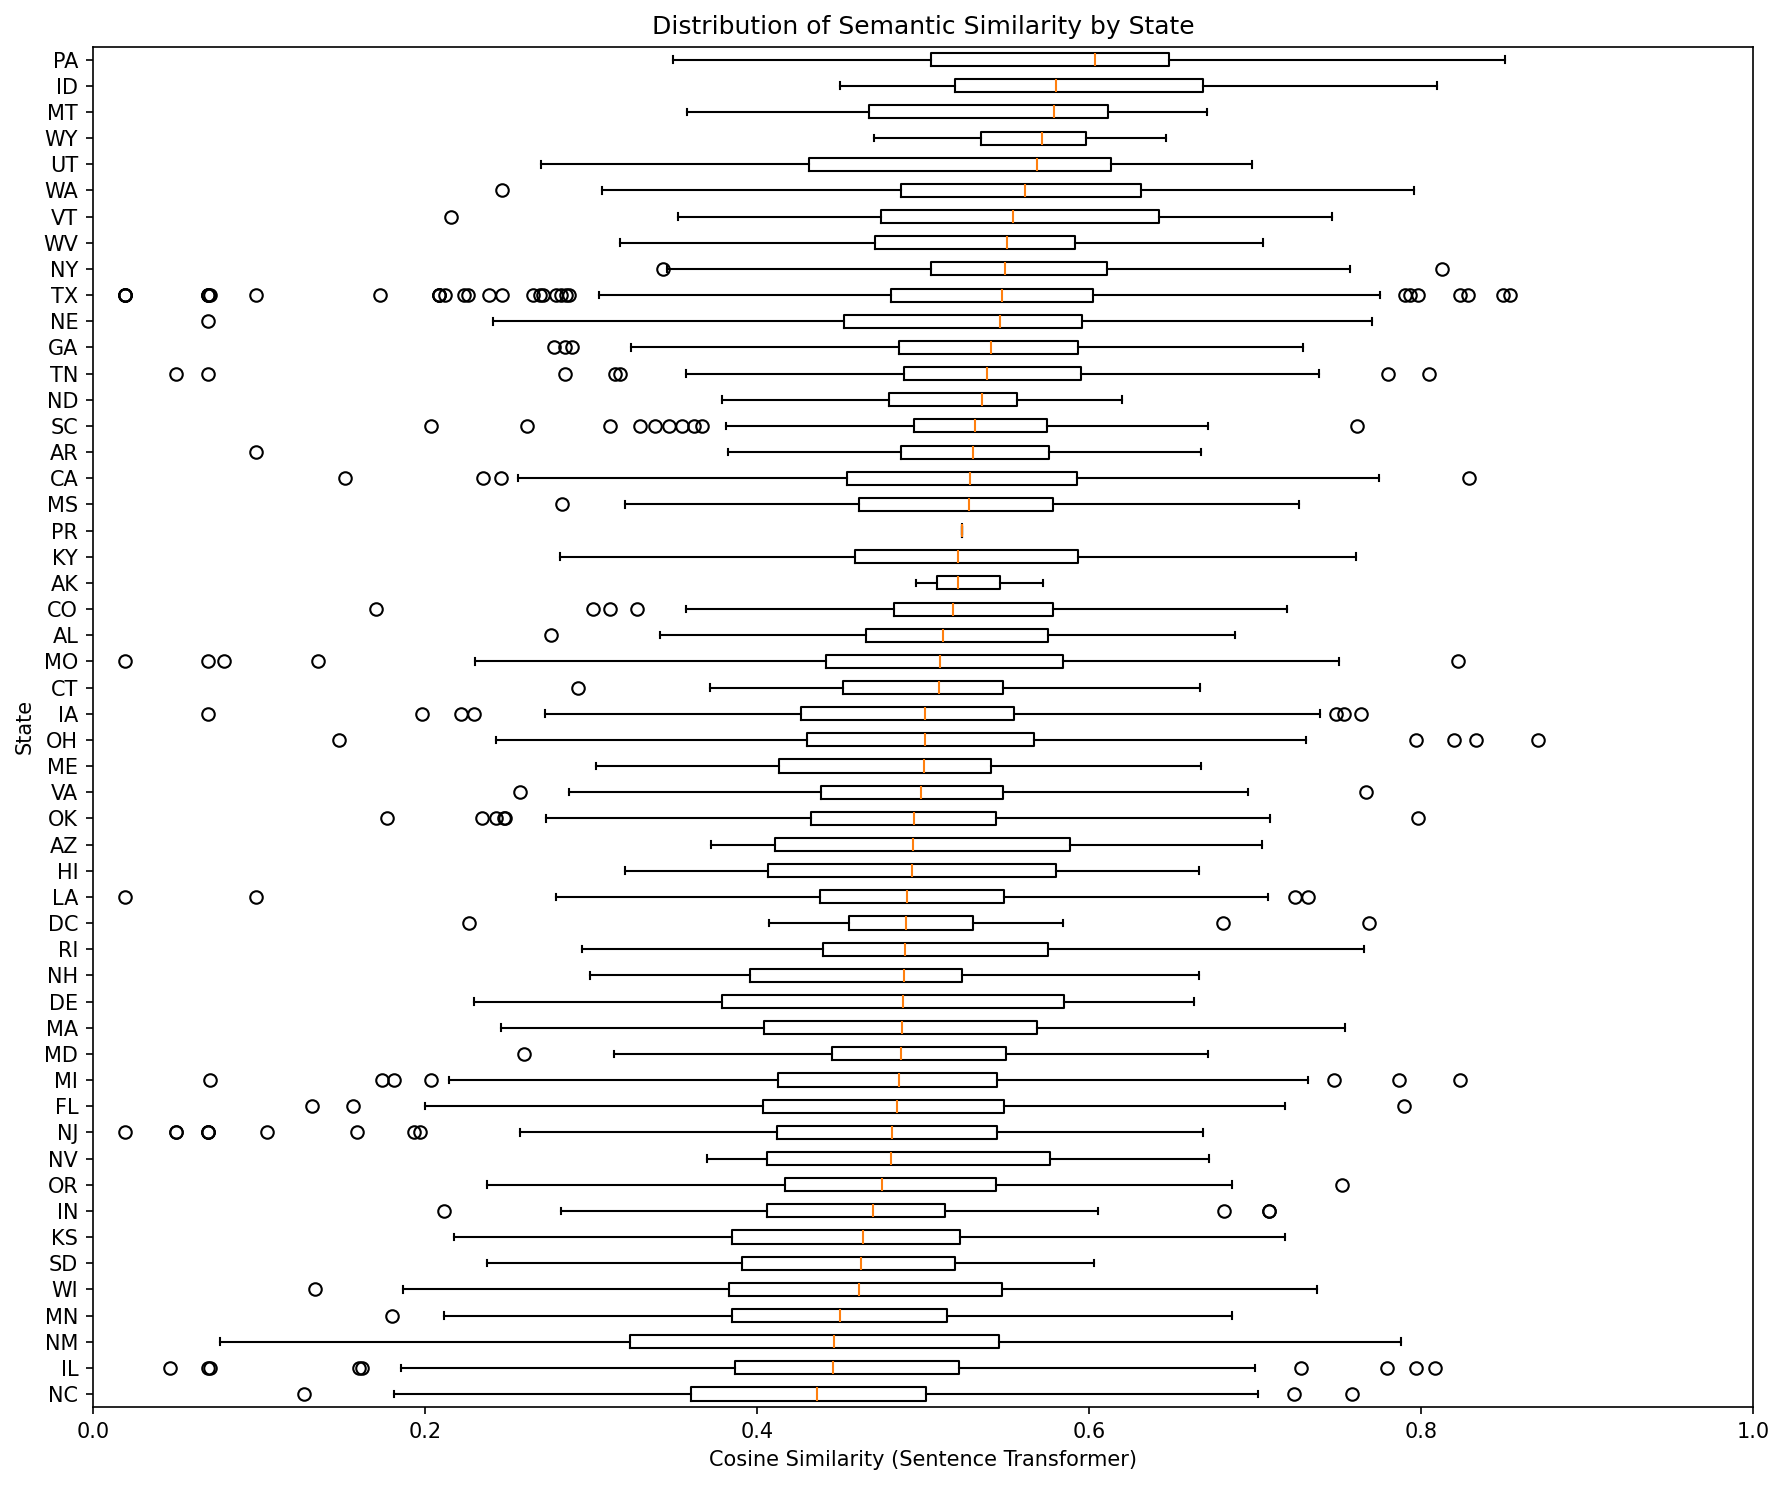

In [30]:
# Optional: sort states by median similarity for cleaner ordering
state_order = (
    citation_filt
    .groupby('state')['sentrans']
    .median()
    .sort_values()
    .index
)

# Prepare data in sorted order
data = [
    citation_filt[citation_filt['state'] == state]['sentrans']
    for state in state_order
]

# Plot
plt.figure(figsize=(12, 10), dpi=150)

plt.boxplot(
    data,
    vert=False
)

plt.yticks(
    ticks=np.arange(1, len(state_order) + 1),
    labels=state_order
)

plt.xlabel('Cosine Similarity (Sentence Transformer)')
plt.ylabel('State')
plt.title('Distribution of Semantic Similarity by State')

plt.xlim(0, 1)

plt.tight_layout()
plt.show()

# Task
Define a Python function `get_citation_analysis` that takes an integer `citation_index` as input. This function will retrieve the `sentrans` similarity score, the `inspection_text`, and the `deficiency_tag` from the `citation_filt` DataFrame. It will then use the `deficiency_tag` to find the associated regulatory text from the `ftag_df` DataFrame. Finally, it will provide a textual interpretation of the similarity score based on predefined ranges and return all this information in a dictionary. After defining the function, demonstrate its usage by calling it with a sample citation index (e.g., 0) and printing the returned details.

## Define get_citation_analysis Function

### Subtask:
Define a Python function `get_citation_analysis` that takes an integer `citation_index` as input. This function will retrieve the `sentrans` similarity score, the `inspection_text`, and the `deficiency_tag` from the `citation_filt` DataFrame. It will then use the `deficiency_tag` to find the associated regulatory text from the `ftag_df` DataFrame. Finally, it will provide a textual interpretation of the similarity score based on predefined ranges and return all this information in a dictionary.


**Reasoning**:
I need to define the `get_citation_analysis` function as per the instructions, which involves retrieving data from two existing dataframes (`citation_filt` and `ftag_df`), formatting a tag, performing a lookup, interpreting a numerical score, and returning a dictionary.



In [31]:
def get_citation_analysis(citation_index: int) -> dict:
  """
  Retrieves and interprets citation analysis data for a given citation index.

  Args:
    citation_index (int): The index of the citation in the `citation_filt` DataFrame.

  Returns:
    dict: A dictionary containing the deficiency tag, inspection text,
          regulatory text, similarity score, and interpretation.
  """
  # Retrieve data from citation_filt DataFrame
  try:
    citation_row = citation_filt.iloc[citation_index]
  except IndexError:
    return {
        "error": "Citation index out of bounds",
        "citation_index": citation_index
    }

  inspection_text = citation_row['inspection_text']
  deficiency_tag_num = citation_row['deficiency_tag']
  similarity_score = citation_row['sentrans']

  # Format the deficiency_tag
  deficiency_tag = f"F{int(deficiency_tag_num)}"

  # Find associated regulatory text from ftag_df
  regulatory_text_row = ftag_df[ftag_df['f_tag'] == deficiency_tag]
  if not regulatory_text_row.empty:
    regulatory_text = regulatory_text_row['text'].iloc[0]
  else:
    regulatory_text = 'Regulatory text not found for this F-tag'

  # Interpret the similarity score
  if similarity_score >= 0.7:
    similarity_interpretation = 'Very High Alignment'
  elif similarity_score >= 0.5:
    similarity_interpretation = 'High Alignment'
  elif similarity_score >= 0.3:
    similarity_interpretation = 'Moderate Alignment'
  else:
    similarity_interpretation = 'Low Alignment'

  return {
      'deficiency_tag': deficiency_tag,
      'inspection_text': inspection_text,
      'regulatory_text': regulatory_text,
      'similarity_score': similarity_score,
      'similarity_interpretation': similarity_interpretation
  }

print("get_citation_analysis function defined.")

get_citation_analysis function defined.


**Reasoning**:
The subtask requires demonstrating the usage of the newly defined `get_citation_analysis` function by calling it with a sample index and printing the output. This will verify the function's correctness and complete the subtask.



In [32]:
sample_citation_index = 0
analysis_results = get_citation_analysis(sample_citation_index)

print(f"\nAnalysis for Citation Index {sample_citation_index}:")
for key, value in analysis_results.items():
    print(f"- {key}: {value}")


Analysis for Citation Index 0:
- deficiency_tag: F600
- inspection_text: **NOTE- TERMS IN BRACKETS HAVE BEEN EDITED TO PROTECT CONFIDENTIALITY** Based on observations, clinical record reviews, review of facility documentation, review of policy and staff interviews for 1 of 5 sampled residents (Resident # 60) reviewed for abuse, the facility failed to ensure the resident was free from abuse and failed to protect other residents following a resident-to-resident altercation resulting in the finding of Immediate Jeopardy and for 4 of 10 residents (Resident # 36, # 43, # 70, # 76), reviewed for abuse, the facility failed to ensure the residents were free from mistreatment. The findings included: <BR/>An observation on 2/28/24 at 1:09 PM, in the dining room identified Resident #76 was standing over Resident #60 who was sitting in a wheelchair in front of her/him delivering three to four blows with a closed fist to the top of Resident #60's head while Recreational Staff #1 was attempting to 

## Final Task

### Subtask:
Confirm the function has been successfully defined and demonstrated, and await further instructions.


## Summary:

### Data Analysis Key Findings

*   The `get_citation_analysis` function was successfully defined, taking an integer `citation_index` as input.
*   The function retrieves `inspection_text`, `deficiency_tag`, and `sentrans` similarity score from the `citation_filt` DataFrame.
*   The numerical `deficiency_tag` is formatted by prepending 'F' (e.g., 600 becomes 'F600') to facilitate lookup.
*   Associated regulatory text is successfully retrieved from the `ftag_df` DataFrame using the formatted `deficiency_tag`. If no match is found, it defaults to 'Regulatory text not found for this F-tag'.
*   Similarity scores are interpreted into four categories: 'Very High Alignment' ($\ge$ 0.7), 'High Alignment' ($\ge$ 0.5), 'Moderate Alignment' ($\ge$ 0.3), and 'Low Alignment' (< 0.3).
*   For a sample similarity score of 0.6338165402412415, the interpretation was 'High Alignment'.
*   The function includes basic error handling for `IndexError` if the `citation_index` is out of bounds.
*   The function returns a dictionary containing the `deficiency_tag`, `inspection_text`, `regulatory_text`, `similarity_score`, and `similarity_interpretation`.
*   The function's functionality was successfully demonstrated by calling it with `sample_citation_index = 0`, producing a detailed analysis.

### Insights or Next Steps

*   The `get_citation_analysis` function provides a structured way to analyze specific citation entries, linking inspection details with regulatory text and interpreting similarity scores for better understanding.
*   Consider expanding the error handling to include cases where `ftag_df` or `citation_filt` DataFrames might be empty or missing expected columns, to ensure robustness.
